<a href="https://colab.research.google.com/github/Allan-Robert/Aulas_Python_20252/blob/main/dados_meteorologicos_Aracaju_20252.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
meteo=pd.read_excel('/content/drive/MyDrive/Colab Notebooks/meteo2020aju.xlsx')
meteo.head(2)

,data,hora,pressão,temperatura_ar,temperatura_máxima,temperatura_mínima,umidade_relativa_ar,dir_vento_angulo,vento_rajada_ms,vel_vento_ms
0,2020-01-01,0,1012.9,27.2,27.2,26.6,62,53,6.5,3.6
1,2020-01-01,1,1012.9,25.5,27.3,25.4,71,18,7.1,3.4


In [ ]:
meteo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   data                 8784 non-null   datetime64[ns]
 1   hora                 8784 non-null   int64         
 2   pressão              8784 non-null   float64       
 3   temperatura_ar       8784 non-null   float64       
 4   temperatura_máxima   8784 non-null   float64       
 5   temperatura_mínima   8784 non-null   float64       
 6   umidade_relativa_ar  8784 non-null   int64         
 7   dir_vento_angulo     8784 non-null   int64         
 8   vento_rajada_ms      8784 non-null   float64       
 9   vel_vento_ms         8784 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(3)
memory usage: 686.4 KB


In [ ]:
### Comparando dados de temperatura mínima e máxima
meteo[['temperatura_mínima','temperatura_máxima']].describe()

,temperatura_mínima,temperatura_máxima
count,8784.000000,8784.000000
mean,26.324419,27.367099
std,2.153276,2.403152
min,19.500000,19.800000
25%,24.800000,25.600000
50%,26.300000,27.100000
75%,27.800000,29.100000
max,32.100000,35.200000


Text(0.5, 1.0, 'Temperaturas máxima e mínima')

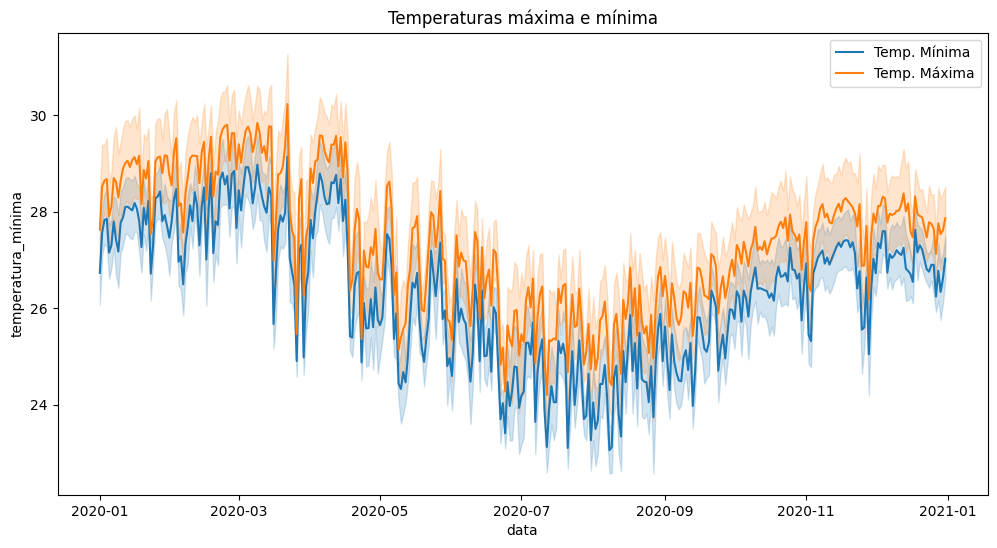

In [6]:
plt.figure(figsize=(12,6))
sns.lineplot(meteo,x='data',y='temperatura_mínima',label='Temp. Mínima')
sns.lineplot(meteo,x='data',y='temperatura_máxima',label='Temp. Máxima')
plt.legend()
plt.title('Temperaturas máxima e mínima')


In [ ]:
### Comparando dados de velocidade do vento e rajada
meteo[['vel_vento_ms','vento_rajada_ms']].describe()

,vel_vento_ms,vento_rajada_ms
count,8784.000000,8784.000000
mean,2.436134,5.934392
std,1.312400,2.070401
min,0.200000,1.100000
25%,1.300000,4.400000
50%,2.200000,6.000000
75%,3.400000,7.400000
max,7.000000,14.000000


Crie uma nova variável chamada Turno com as seguintes respostas:
* Matutino 6:00 às 11:59,
* Vespertino 12:00 às 17:59,
* Noturno 18:00 às 23:59 e
* Madrugada 00:00 às 05:59.

In [7]:
turnos=['Madrugada','Matutino','Vespertino','Noturno']
intervalos=[0,6,12,18,24]
meteo['Turno']=pd.cut(meteo['hora'],bins=intervalos,labels=turnos,right=False)
meteo.Turno.value_counts()

,count
Turno,
Madrugada,2196
Matutino,2196
Vespertino,2196
Noturno,2196


In [ ]:
## Descritiva de vento por turno
meteo.groupby('Turno')['vel_vento_ms'].describe()


/tmp/ipython-input-4082534239.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meteo.groupby('Turno')['vel_vento_ms'].describe()


,count,mean,std,min,25%,50%,75%,max
Turno,,,,,,,,
Madrugada,2196.0,2.273042,1.237339,0.2,1.2,2.0,3.3,5.8
Matutino,2196.0,2.028415,1.092043,0.2,1.1,1.7,2.8,7.0
Vespertino,2196.0,2.949727,1.286193,0.4,1.9,2.8,3.9,6.2
Noturno,2196.0,2.493352,1.433171,0.3,1.3,2.1,3.7,6.7


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


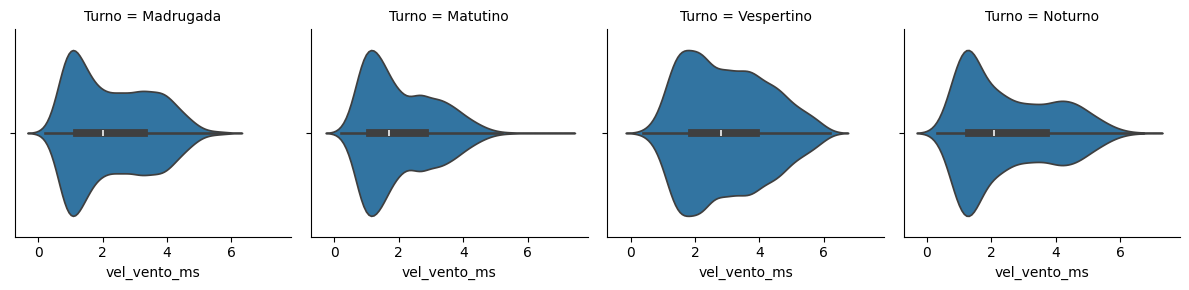

In [10]:
gr=sns.FacetGrid(meteo,col='Turno')
gr.map(sns.violinplot,'vel_vento_ms')

Crie uma nova variável chamada Estação com as seguintes **categorias**:

* Primavera: 22 de setembro a 20 de dezembro;
* Verão: 21 de dezembro a 19 de março;
* Outono: 20 de março a 20 de junho;
* Inverno: 21 de junho a 21 de setembro.

In [11]:
def est(x):
  if x < pd.to_datetime('2020-03-20'):
    return 'Verão'
  elif x < pd.to_datetime('2020-06-20'):
    return 'Outono'
  elif x < pd.to_datetime('2020-09-21'):
    return 'Inverno'
  elif x < pd.to_datetime('2020-12-20'):
    return 'Primavera'
  else: return 'Verão'

meteo['Estação']=meteo['data'].apply(est)
meteo.Estação.value_counts()

,count
Estação,
Inverno,2232
Outono,2208
Verão,2184
Primavera,2160


In [ ]:
# descrivas de temperatura para estação e turno
meteo.groupby(['Estação','Turno'])['temperatura_ar'].describe()

/tmp/ipython-input-2391454761.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meteo.groupby(['Estação','Turno'])['temperatura_ar'].describe()


count       mean       std   min     25%    50%   75%  \
Estação   Turno                                                               
Inverno   Madrugada   558.0  24.046595  1.029588  20.6  23.400  24.30  24.8   
          Matutino    558.0  23.753763  1.437499  19.7  22.600  23.80  24.6   
          Vespertino  558.0  27.393369  1.425886  22.5  26.800  27.70  28.3   
          Noturno     558.0  25.500179  1.459415  21.9  24.525  25.30  26.5   
Outono    Madrugada   552.0  25.931159  1.380841  22.4  25.000  26.00  26.9   
          Matutino    552.0  25.321377  1.645181  21.4  24.000  25.20  26.4   
          Vespertino  552.0  29.094022  2.067171  23.5  28.000  29.50  30.6   
          Noturno     552.0  27.267210  1.748422  23.4  26.100  27.20  28.4   
Primavera Madrugada   540.0  25.749074  0.713544  22.4  25.400  25.90  26.2   
          Matutino    540.0  26.005370  1.464999  22.0  25.200  25.85  26.7   
          Vespertino  540.0  29.369444  0.934959  23.3  28.975  29.50  29.9   
          Noturno     540.0  27.071667  1.263103  23.6  26.200  26.80  28.1   
Verão     Madrugada   546.0  27.099084  0.854078  24.1  26.600  27.20  27.7   
          Matutino    546.0  26.919048  1.372938  23.9  26.000  26.80  27.6   
          Vespertino  546.0  30.409707  1.264808  25.4  29.600  30.70  31.3   
          Noturno     546.0  28.595238  1.316729  25.0  27.600  28.40  29.5   

                       max  
Estação   Turno             
Inverno   Madrugada   26.1  
          Matutino    27.7  
          Vespertino  29.9  
          Noturno     29.0  
Outono    Madrugada   29.1  
          Matutino    30.9  
          Vespertino  33.6  
          Noturno     31.9  
Primavera Madrugada   27.1  
          Matutino    29.9  
          Vespertino  33.4  
          Noturno     30.8  
Verão     Madrugada   28.8  
          Matutino    31.2  
          Vespertino  33.2  
          Noturno     31.9

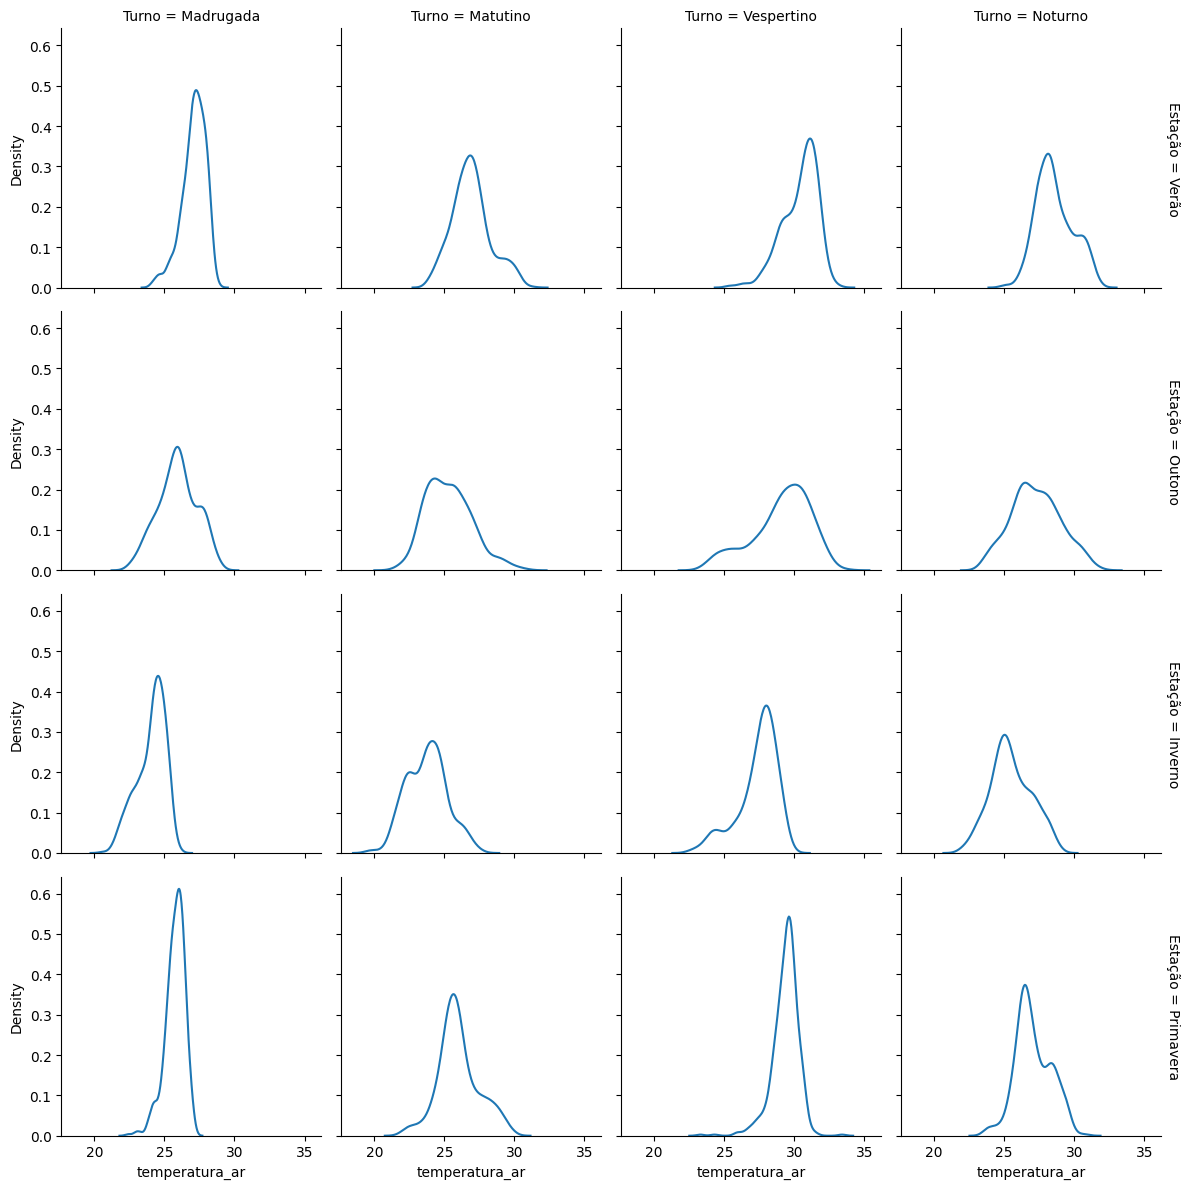

In [15]:
gr=sns.FacetGrid(meteo,row='Estação',col='Turno',margin_titles=True)
gr.map(sns.kdeplot,'temperatura_ar')

In [ ]:
meteo.vel_vento_ms.max()

7.0

In [21]:
limites_beaufort = [0,0.2, 1.5, 3.3, 5.4, 7.9] # Até Brisa moderada

# Defina os rótulos para cada categoria da escala de Beaufort
rotulos_beaufort = ['Calmaria','Aragem', 'Brisa leve', 'Brisa fraca', 'Brisa moderada'] # Até Brisa moderada

# Crie a nova coluna 'Beaufort' usando pd.cut
meteo['Beaufort'] = pd.cut(meteo['vel_vento_ms'],
                            bins=limites_beaufort, # Adiciona 0 como limite inferior e um valor maior que o máximo como limite superior
                            labels=rotulos_beaufort, # Adiciona None para valores fora da faixa de rótulos definidos (acima de brisa moderada)
                            ) # Inclui o limite superior no intervalo
meteo['Beaufort'].value_counts()

,count
Beaufort,
Brisa leve,3468
Aragem,2979
Brisa fraca,2203
Brisa moderada,132
Calmaria,2


/tmp/ipython-input-2366520516.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=meteo,x='Beaufort',kind='count',palette='Set2')


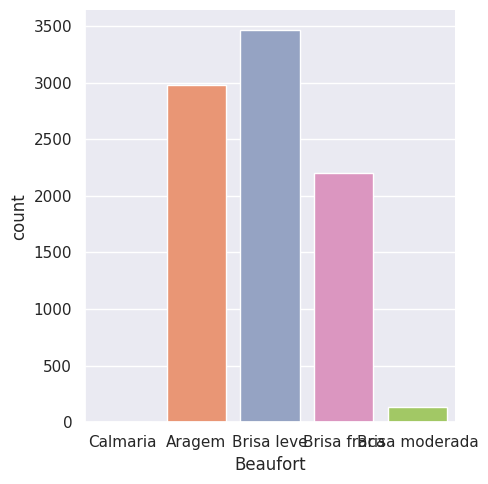

In [37]:
sns.catplot(data=meteo,x='Beaufort',kind='count',palette='Set2')

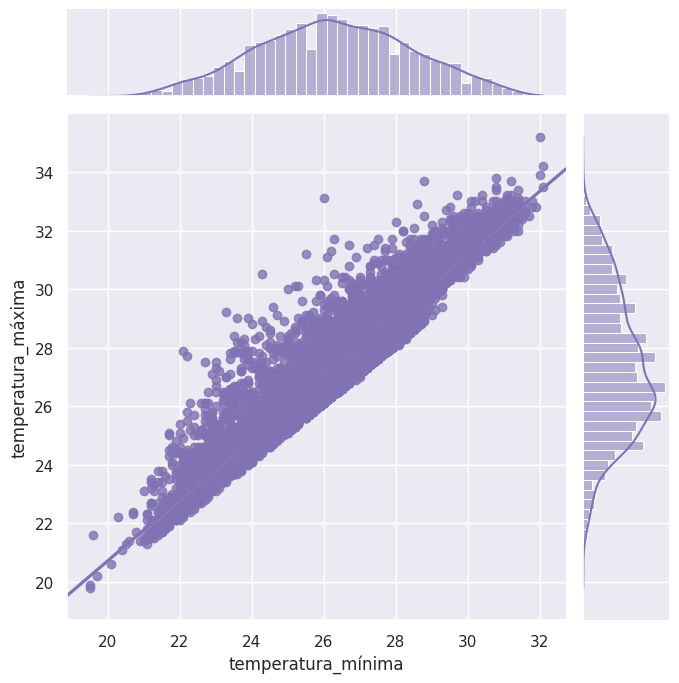

In [20]:
### relação temperatura máxima e mínima
sns.set_theme(style="darkgrid")

g = sns.jointplot(x="temperatura_mínima", y="temperatura_máxima", data=meteo,
                  kind="reg", truncate=False,
                  color="m", height=7)
